# Unit VII Mini-Lab: The Signal Behind AlphaFold2
### Machine Learning in the Sciences

**Goal:** recover a "protein's" 3D contact map from sequence data alone, using the same core insight that AlphaFold2 was built around -- and watch it fail completely without that insight.

AlphaFold2 (Jumper et al., 2021) predicts a protein's 3D structure from its amino acid sequence, and its architecture (the "Evoformer") is built specifically to exploit **evolutionary co-variation**: when two positions in a protein are in physical contact in the folded structure, mutations at those two positions tend to be *correlated* across evolutionarily related sequences, because a mutation at one often has to be compensated by a mutation at the other to keep the protein stable. This idea -- long before deep learning was involved -- is called **co-evolution** or **direct coupling analysis**, and it's the single biggest reason AlphaFold needs a *family* of related sequences (a multiple sequence alignment, or MSA) rather than just the one sequence you're trying to fold.

This notebook builds a small synthetic "protein family" with a known ground-truth contact map, and compares two ways of trying to recover that contact map:
- **(a)** guessing contacts from a single sequence alone
- **(b)** using mutual information across a family of related sequences -- the co-evolution signal

## How to run this notebook

- Run cells **top to bottom** with **Shift+Enter**.
- Everything is fully provided and synthetic -- no downloads, no accounts, no biology software needed.
- The **"Try this yourself"** section near the end has parameters meant to be edited -- including one (family size) that reproduces a real, well-documented AlphaFold limitation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 0
rng = np.random.default_rng(RANDOM_STATE)

L = 30              # sequence length (number of "residue" positions)
ALPHABET = 4        # simplified "residue types" (real proteins use 20 amino acids)
N_CONTACTS = 15     # how many true 3D contacts our toy fold has
MIN_SEPARATION = 4  # only positions at least this far apart count as a real tertiary contact

print("Libraries loaded.")

Libraries loaded.


## Step 1 — Build a ground-truth "fold"

We won't simulate real 3D folding -- instead we directly define a **true contact map**: a set of position pairs that are meant to be near each other in the (imaginary) folded structure. This is exactly the thing AlphaFold2 is trying to predict for a real protein, except here we get to know the right answer in advance.

In [2]:
all_possible_pairs = [(i, j) for i in range(L) for j in range(i + MIN_SEPARATION, L)]
rng.shuffle(all_possible_pairs)
true_contacts = set(all_possible_pairs[:N_CONTACTS])

base_sequence = rng.integers(0, ALPHABET, size=L)

print(f"Sequence length: {L}, true contacts: {N_CONTACTS}")
print("A few true contacts:", sorted(true_contacts)[:5], "...")

Sequence length: 30, true contacts: 15
A few true contacts: [(0, 22), (2, 25), (3, 7), (4, 21), (4, 27)] ...


## Step 2 — Build a family of related sequences

Starting from the base sequence, generate many "evolutionarily related" variants. Most positions mutate independently and randomly. But at the true contact positions, we impose a simple **coupling rule**: a mutation at one side of a contact tends to force a compensating change on the other side, exactly the compensatory-mutation mechanism that produces real co-evolution signal. `coupling_noise` controls how often that compensation actually happens -- real biology isn't perfectly deterministic either.

In [3]:
def coupled_letter(x):
    """A fixed, arbitrary pairing rule standing in for a real structural compatibility constraint."""
    return (x + 2) % ALPHABET

def generate_family(n_seqs, mutation_rate, coupling_noise, rng):
    seqs = np.zeros((n_seqs, L), dtype=int)
    for s in range(n_seqs):
        seq = base_sequence.copy()
        mut_mask = rng.random(L) < mutation_rate
        seq[mut_mask] = rng.integers(0, ALPHABET, size=mut_mask.sum())
        for (i, j) in true_contacts:
            if rng.random() > coupling_noise:
                seq[j] = coupled_letter(seq[i])
        seqs[s] = seq
    return seqs

N_SEQS = 200
MUTATION_RATE = 0.3
COUPLING_NOISE = 0.1

family = generate_family(N_SEQS, MUTATION_RATE, COUPLING_NOISE, rng)
print("Family (our synthetic MSA) shape:", family.shape, "-- rows are sequences, columns are positions.")

Family (our synthetic MSA) shape: (200, 30) -- rows are sequences, columns are positions.


## Step 3a — The naive approach: guess from one sequence alone

Without any family information, about the only thing you could try is some heuristic based on a single sequence -- here, just ranking position pairs by how *different* their residue types are. There's no real reason this should recover 3D contacts, and that's exactly the point: **a single sequence, on its own, does not contain enough information to tell you which positions are in contact.**

In [4]:
def top_k_precision(predicted_pairs, k):
    return len(set(predicted_pairs[:k]) & true_contacts) / k

single_sequence = family[0]
candidate_pairs = all_possible_pairs  # every eligible (i, j), same candidate set for both methods

naive_scores = [-abs(int(single_sequence[i]) - int(single_sequence[j])) for (i, j) in candidate_pairs]
naive_ranked = [candidate_pairs[idx] for idx in np.argsort(naive_scores)[::-1]]
naive_precision = top_k_precision(naive_ranked, N_CONTACTS)

chance_level = N_CONTACTS / len(candidate_pairs)
print(f"Naive single-sequence precision @ top-{N_CONTACTS}: {naive_precision:.3f}")
print(f"(random-guess chance level would be about {chance_level:.3f})")

Naive single-sequence precision @ top-15: 0.000
(random-guess chance level would be about 0.043)


## Step 3b — The co-evolution approach: mutual information across the family

For every pair of positions, compute the **mutual information** between the two columns across the whole family: how much does knowing the residue at position *i* tell you about the residue at position *j*, across all these related sequences? At true contacts, this should be high (because of the coupling we built in); everywhere else, it should be close to zero.

In [5]:
def mutual_information(col_i, col_j, alphabet):
    mi = 0.0
    for a in range(alphabet):
        for b in range(alphabet):
            p_ab = np.mean((col_i == a) & (col_j == b))
            p_a = np.mean(col_i == a)
            p_b = np.mean(col_j == b)
            if p_ab > 0 and p_a > 0 and p_b > 0:
                mi += p_ab * np.log(p_ab / (p_a * p_b))
    return mi

def compute_mi_matrix(family, alphabet):
    n_pos = family.shape[1]
    mi_matrix = np.zeros((n_pos, n_pos))
    for i in range(n_pos):
        for j in range(i + 1, n_pos):
            mi = mutual_information(family[:, i], family[:, j], alphabet)
            mi_matrix[i, j] = mi
            mi_matrix[j, i] = mi
    return mi_matrix

mi_matrix = compute_mi_matrix(family, ALPHABET)

mi_scores = [mi_matrix[i, j] for (i, j) in candidate_pairs]
mi_ranked = [candidate_pairs[idx] for idx in np.argsort(mi_scores)[::-1]]
mi_precision = top_k_precision(mi_ranked, N_CONTACTS)

print(f"Co-evolution (mutual information) precision @ top-{N_CONTACTS}: {mi_precision:.3f}")

Co-evolution (mutual information) precision @ top-15: 0.733


## Step 4 — Compare visually

Three contact maps side by side: the true one, the naive method's top guesses, and the co-evolution method's top guesses.

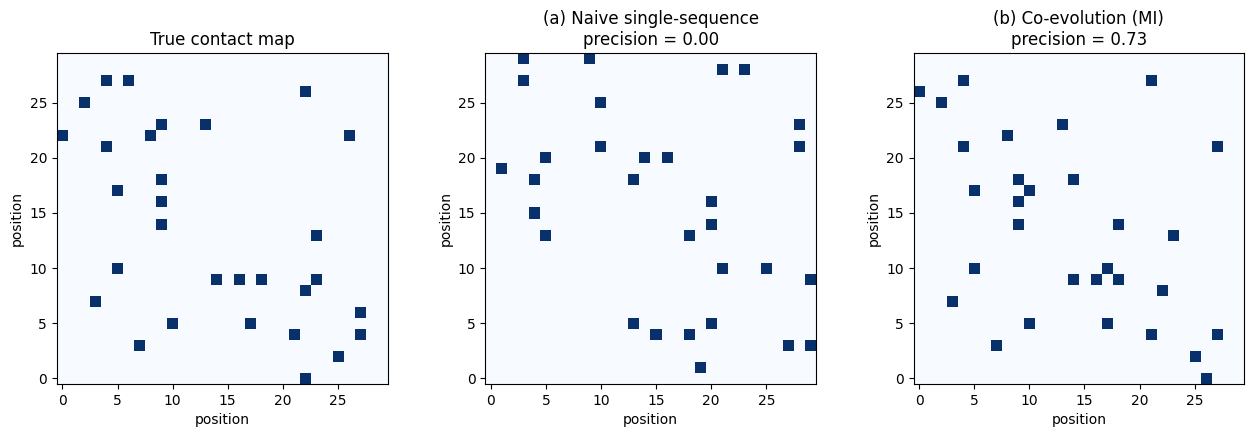

In [6]:
def contacts_to_matrix(pairs, L):
    m = np.zeros((L, L))
    for (i, j) in pairs:
        m[i, j] = 1
        m[j, i] = 1
    return m

true_matrix = contacts_to_matrix(true_contacts, L)
naive_matrix = contacts_to_matrix(naive_ranked[:N_CONTACTS], L)
mi_matrix_pred = contacts_to_matrix(mi_ranked[:N_CONTACTS], L)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
titles = [
    f"True contact map",
    f"(a) Naive single-sequence\nprecision = {naive_precision:.2f}",
    f"(b) Co-evolution (MI)\nprecision = {mi_precision:.2f}",
]
for ax, mat, title in zip(axes, [true_matrix, naive_matrix, mi_matrix_pred], titles):
    ax.imshow(mat, cmap="Blues", origin="lower")
    ax.set_title(title)
    ax.set_xlabel("position")
    ax.set_ylabel("position")
fig.tight_layout()
plt.show(block=False)

If this ran as intended, (a) should look close to random scatter with precision near the chance level, while (b) should visibly line up with the true contact map, at least approximately.

## Step 5 — Try this yourself

**1. The big one: vary the family size.** This is the same reason AlphaFold2 struggles on **orphan proteins** -- ones with few known evolutionary relatives. Run the cell below as-is first, then come back and think about the shape of the curve.

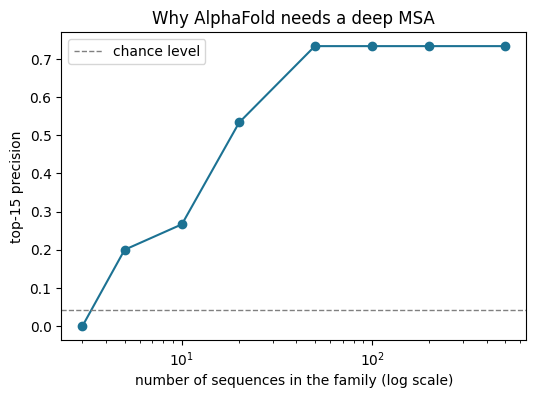

In [7]:
family_sizes = [3, 5, 10, 20, 50, 100, 200, 500]
precisions = []

for n in family_sizes:
    fam = generate_family(n, MUTATION_RATE, COUPLING_NOISE, rng)
    mi_mat = compute_mi_matrix(fam, ALPHABET)
    scores = [mi_mat[i, j] for (i, j) in candidate_pairs]
    ranked = [candidate_pairs[idx] for idx in np.argsort(scores)[::-1]]
    precisions.append(top_k_precision(ranked, N_CONTACTS))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(family_sizes, precisions, marker="o", color="#1C7293")
ax.axhline(chance_level, color="gray", linestyle="--", linewidth=1, label="chance level")
ax.set_xscale("log")
ax.set_xlabel("number of sequences in the family (log scale)")
ax.set_ylabel(f"top-{N_CONTACTS} precision")
ax.set_title("Why AlphaFold needs a deep MSA")
ax.legend()
plt.show(block=False)

**More things to try:**

**2. Turn up `COUPLING_NOISE`** (in Step 2, e.g. to `0.5` or `0.8`) and regenerate the family. This is like a weaker structural constraint -- how much does it take before the co-evolution signal becomes too noisy to recover?

**3. Turn down `MUTATION_RATE`** to something very small (e.g. `0.02`). If almost nothing mutates, there's very little variation to compute mutual information *from*, even with a large family. Does precision suffer for a different reason than the family-size experiment above?

**4. Try a cheaper substitute for mutual information.** Mutual information requires enough data per pair to estimate a full alphabet-by-alphabet frequency table, which gets expensive for a large alphabet (real proteins have 20 amino acids, not 4). Try simple column-wise covariance or a chi-squared statistic instead, and see whether it recovers contacts about as well with less computation.

**5. Increase `N_CONTACTS` or `L`.** Does the method hold up with a bigger, more realistic contact map?

In [ ]:
# space for your own experiments above






## Reflection

1. Why does the naive single-sequence method have no real chance of working here, no matter how clever the heuristic is?
2. The family-size curve should show a clear "knee" -- performance is poor below some threshold, then improves and levels off. Why would a real biological protein family, not just this toy one, tend to plateau rather than keep improving forever as you add more sequences?
3. AlphaFold2's Evoformer does much more than compute a simple mutual information matrix -- it's a learned, iteratively-refined attention mechanism over both the sequence family and the pairwise representation simultaneously. Based on what you just built by hand, what do you think a learned attention mechanism could pick up on that a fixed statistic like mutual information cannot?

## References

- Jumper, J., Evans, R., Pritzel, A. et al., 2021, “Highly accurate protein structure prediction with AlphaFold,” *Nature* 596, 583–589
- Weigt, White, Szurmant, Hoch & Hwa, 2009, “Identification of direct residue contacts in protein-protein interaction by message passing,” *PNAS* — an early statement of the co-evolution/direct-coupling idea this notebook simplifies
- Morcos et al., 2011, “Direct-coupling analysis of residue coevolution captures native contacts across many protein families,” *PNAS*
- Ovchinnikov, Kamisetty & Baker, 2014, “Robust and accurate prediction of residue-residue interactions across protein interfaces using evolutionary information,” *eLife* (GREMLIN)
- Mirdita et al., 2022, “ColabFold: making protein folding accessible to all,” *Nature Methods* — the widely-used, free-to-run community implementation

**Code & data:** github.com/google-deepmind/alphafold (official release); the AlphaFold Protein Structure Database at alphafold.ebi.ac.uk; ColabFold at github.com/sokrypton/ColabFold for a lighter-weight way to actually run structure prediction on a real sequence.